# 01 Data Preprocessing

Objective: Handle missing values, scaling, and initial data cleaning.


In [39]:
import pandas as pd
import numpy as np

In [40]:
file_path = r"C:\Users\David\BTC-trend-prediction\data\raw\coin_Bitcoin.csv"

df = pd.read_csv(file_path, parse_dates=['Date'])

df.head()

,SNo,Name,Symbol,Date,High,Low,Open,Close,Volume,Marketcap
0,1,Bitcoin,BTC,2013-04-29 23:59:59,147.488007,134.000000,134.444000,144.539993,0.0,1.603769e+09
1,2,Bitcoin,BTC,2013-04-30 23:59:59,146.929993,134.050003,144.000000,139.000000,0.0,1.542813e+09
2,3,Bitcoin,BTC,2013-05-01 23:59:59,139.889999,107.720001,139.000000,116.989998,0.0,1.298955e+09
3,4,Bitcoin,BTC,2013-05-02 23:59:59,125.599998,92.281898,116.379997,105.209999,0.0,1.168517e+09
4,5,Bitcoin,BTC,2013-05-03 23:59:59,108.127998,79.099998,106.250000,97.750000,0.0,1.085995e+09


In [41]:
df = df.sort_values('Date').reset_index(drop=True)
#sorting dates from oldest to newest, but in this case it already did

In [42]:
df.isnull().sum()
#checking for missing data
#no missing values in this dataset

SNo          0
Name         0
Symbol       0
Date         0
High         0
Low          0
Open         0
Close        0
Volume       0
Marketcap    0
dtype: int64

In [43]:

df.drop(columns=['SNo','Name','Symbol'], inplace=True)

In [44]:
df['Log_Ret'] = np.log(df['Close'] / df['Close'].shift(1))
df = df.dropna()

# 02 EDA


Objective: Understand the BTC-USD price dataset, visualize distributions, and identify outliers or seasonal trends.



In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

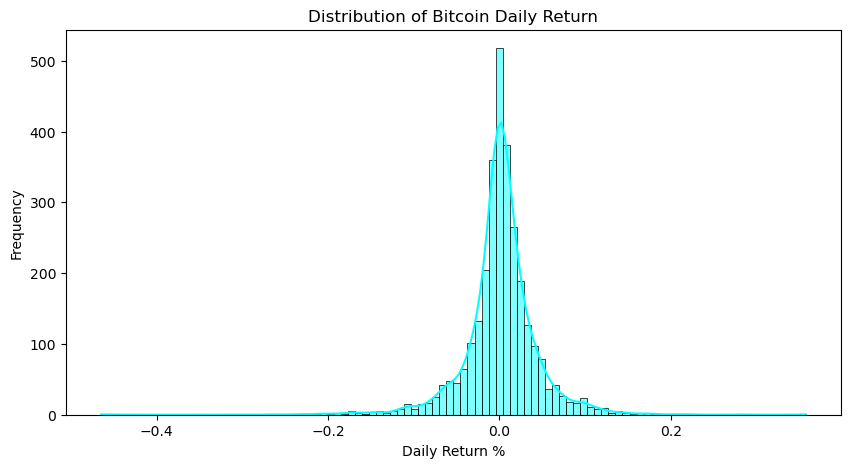

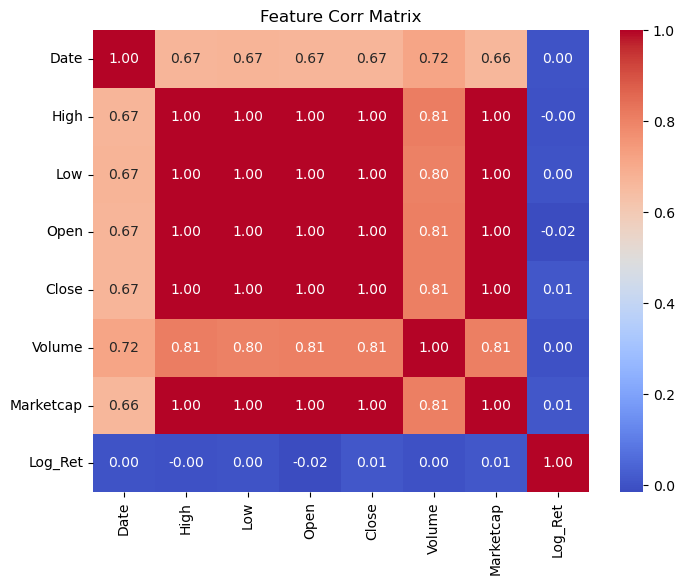

Bitcoin closes green 54.01% of the time


In [46]:
plt.figure(figsize=(10,5))
sns.histplot(df['Log_Ret'], bins=100, kde=True, color='cyan')
plt.title('Distribution of Bitcoin Daily Return')
plt.xlabel('Daily Return %')
plt.ylabel('Frequency')
plt.show

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Corr Matrix')
plt.show()

#calculates how oftern bitcoin goes up
win_rate = (df['Log_Ret'] > 0).mean() * 100
print(f"Bitcoin closes green {win_rate:.2f}% of the time")


# 03 Feature Engineering

Objective: Create technical indicators (RSI, SMA, MACD) and prepare the feature matrix.

In [47]:
# Log Returns & Volatility (Stationary metrics)
df['Log_Ret'] = np.log(df['Close'] / df['Close'].shift(1))
df['Vol_20'] = df['Log_Ret'].rolling(window=20).std()


# Relative Moving Averages (Distances)
df['MA13_Dist'] = (df['Close'] - df['Close'].rolling(13).mean()) / df['Close'].rolling(13).mean()
df['MA21_Dist'] = (df['Close'] - df['Close'].rolling(21).mean()) / df['Close'].rolling(21).mean()

# Momentum (Z-Score & RSI)
df['Z_Score'] = (df['Close'] - df['Close'].rolling(20).mean()) / (df['Close'].rolling(20).std())

delta = df['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=5).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=5).mean()
df['RSI_5'] = 100 - (100 / (1 + (gain / loss)))

### We add new perimeter to detect Whale's activity

In [48]:
# Whale Detection (VSA Features) ---
# RVOL: Suspicious Volume
df['RVOL'] = df['Volume'] / df['Volume'].rolling(window=20).mean()
# VP_Divergence: Is volume backing the move?
df['VP_Divergence'] = df['Log_Ret'] * df['RVOL']
# OBV_Slope: Accumulation/Distribution
df['OBV'] = (np.sign(df['Log_Ret']) * df['Volume']).cumsum()
df['OBV_Slope'] = df['OBV'].diff(5) / df['OBV'].rolling(20).std()
# Absorption: Large volume on small price spread
df['Vol_Efficiency'] = (df['High'] - df['Low']) / df['Volume']

In [49]:
# Define the Target (3-Day Horizon) 
# We want the model to predict if the price will be > 1.5% higher in 3 days
df['Future_3D_Ret'] = (df['Close'].shift(-3) - df['Open'].shift(-1)) / df['Open'].shift(-1)
df['Target'] = (df['Future_3D_Ret'] > 0.015).astype(int)

# Cleanup & The "Price Blind" Purge ---
# Drop all NaNs from rolling windows and shifts
df = df.dropna()

In [50]:
# Final Clean & Save ---
df = df.dropna()

features_v4 = [
    'Date', 'Target', 'Log_Ret', 'Vol_20', 'MA13_Dist', 'MA21_Dist', 
    'Z_Score', 'RSI_5', 'RVOL', 'VP_Divergence', 'OBV_Slope', 'Vol_Efficiency'
]

df_final = df[features_v4]
save_path = r'C:\Users\David\BTC-trend-prediction\data\processed\btc_alpha_v4.csv'
df_final.to_csv(save_path, index=False)

### Removed Vol Efficiency features

In [51]:


df['Future_3D_Ret'] = (df['Close'].shift(-3) - df['Open'].shift(-1)) / df['Open'].shift(-1)
df['Target'] = (df['Future_3D_Ret'] > 0.015).astype(int)
df = df.dropna()

features_v5 = [
    'Date', 'Target', 'Log_Ret', 'Vol_20', 'MA13_Dist', 'MA21_Dist', 
    'Z_Score', 'RSI_5', 'RVOL', 'VP_Divergence', 'OBV_Slope'
]
df_final1 = df[features_v5]
save_path = r'C:\Users\David\BTC-trend-prediction\data\processed\btc_alpha_v5.csv'
df_final1.to_csv(save_path, index=False)

# 04 Model Training

Objective: Train and tune machine learning models using Random Forest for BTC trend prediction.

In [52]:

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, classification_report, confusion_matrix

In [53]:

# Load the Vault Data ---
df = pd.read_csv(r'C:\Users\David\BTC-trend-prediction\data\processed\btc_alpha_v5.csv', parse_dates=['Date'])

# Define Features (X) and Target (y) ---
# CRITICAL: We MUST drop 'Next_Day_Return' because it is literally tomorrow's data. 
# If the model sees it, it achieves 100% accuracy by cheating.

X = df.drop(columns=['Date', 'Target'])
y = df['Target']

# --- STEP 3: Chronological Split (No Time Travel) ---
split_idx = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split_idx - 3], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx - 3], y.iloc[split_idx:]

print(f"Training on {len(X_train)} days. Testing on {len(X_test)} days.")

# --- STEP 4: Standardize the Features ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



Training on 2191 days. Testing on 549 days.


In [54]:
df.head()

,Date,Target,Log_Ret,Vol_20,MA13_Dist,MA21_Dist,Z_Score,RSI_5,RVOL,VP_Divergence,OBV_Slope
0,2013-12-27 23:59:59,1,-0.035955,0.122779,0.080340,-0.019159,-0.135562,81.459170,20.000000,-0.719091,-4.472136
1,2013-12-28 23:59:59,1,-0.009898,0.119013,0.087938,-0.030643,-0.166759,69.663279,8.191109,-0.081077,-3.942890
2,2013-12-29 23:59:59,1,0.023384,0.115874,0.108696,-0.004500,0.032327,76.889770,3.864879,0.090375,-2.580104
3,2013-12-30 23:59:59,1,0.014762,0.113114,0.115732,0.019192,0.253500,75.987917,3.477729,0.051338,-1.636630
4,2013-12-31 23:59:59,1,-0.002808,0.110407,0.084140,0.031866,0.309706,43.828421,2.985653,-0.008383,-2.291541


In [55]:
# Initialize and Train the Brain ---
# random_state=42 ensures we get the exact same results every time we run this cell
model = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, min_samples_split=10)

print("Training model... (This might take a few seconds depending on your CPU)")
model.fit(X_train_scaled, y_train)

# --- STEP 6: Make Predictions on the Unseen Future (Test Set) ---
y_pred = model.predict(X_test_scaled)

# --- STEP 7: Evaluate Precision ---
precision = precision_score(y_test, y_pred)
print("\n--- RESULTS ---")
print(f"Model Precision: {precision * 100:.2f}%")

# Let's look at the exact breakdown
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Training model... (This might take a few seconds depending on your CPU)

--- RESULTS ---
Model Precision: 50.66%

Confusion Matrix:
[[224  75]
 [173  77]]


### Lets test feature importance

C:\Users\David\AppData\Local\Temp\ipykernel_35964\1152285350.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')


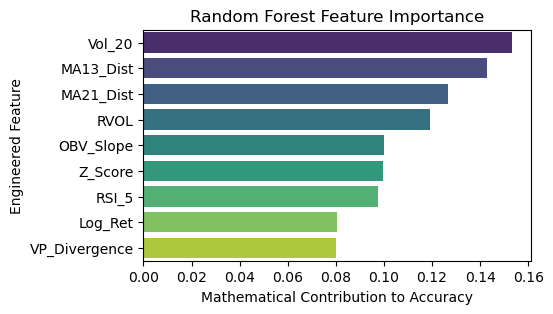

         Feature  Importance
1         Vol_20    0.153388
2      MA13_Dist    0.143015
3      MA21_Dist    0.126657
6           RVOL    0.119239
8      OBV_Slope    0.100130
4        Z_Score    0.099674
5          RSI_5    0.097609
0        Log_Ret    0.080369
7  VP_Divergence    0.079920


In [56]:

# --- STEP 1: Extract the ML Logic ---
# The model remembers which features actually helped it reduce errors.
importances = model.feature_importances_

# Bind the numbers back to the column names
feature_names = X.columns
feature_imp_df = pd.DataFrame({
    'Feature': feature_names, 
    'Importance': importances
}).sort_values('Importance', ascending=False)

# --- STEP 2: Visualize the Truth ---
plt.figure(figsize=(5, 3))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title('Random Forest Feature Importance')
plt.xlabel('Mathematical Contribution to Accuracy')
plt.ylabel('Engineered Feature')
plt.show()

print(feature_imp_df)

<Axes: >

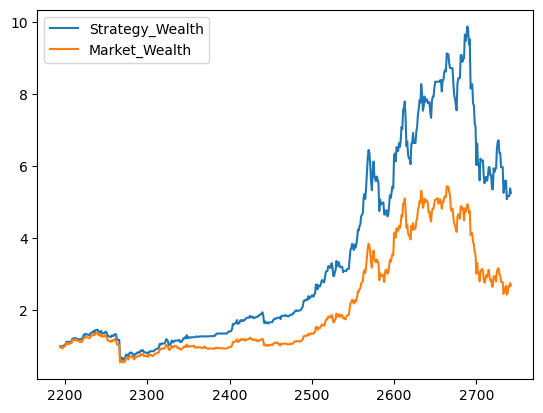

In [57]:
# Create the backtest dataframe and RESET the index to align everything
backtest_df = X_test.copy()

# We find the returns for the EXACT dates used in X_test
backtest_df['Actual_Return'] = df.loc[X_test.index, 'Log_Ret'].values

# Probabilities
backtest_df['Prob_Up'] = model.predict_proba(X_test_scaled)[:, 1]

# Signal
backtest_df['Signal'] = (backtest_df['Prob_Up'] > 0.3).astype(int)

# Growth of $1
backtest_df['Strategy_Wealth'] = (1 + (backtest_df['Signal'] * backtest_df['Actual_Return'])).cumprod()
backtest_df['Market_Wealth'] = (1 + backtest_df['Actual_Return']).cumprod()

backtest_df[['Strategy_Wealth', 'Market_Wealth']].plot()

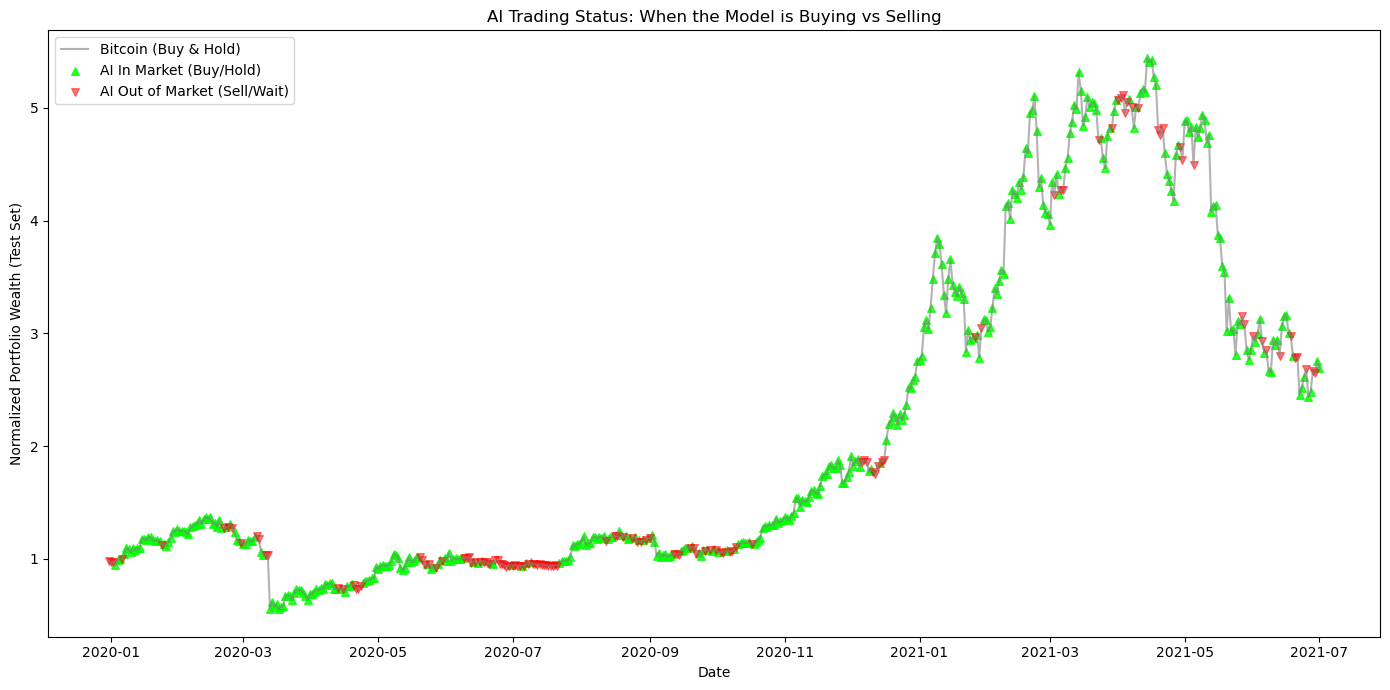

In [58]:
import matplotlib.pyplot as plt

# Bring in dates for plotting
backtest_df['Date'] = df.loc[X_test.index, 'Date'].values

plt.figure(figsize=(14, 7))
# Plot the baseline 'price' shape (Market Wealth)
plt.plot(backtest_df['Date'], backtest_df['Market_Wealth'], label='Bitcoin (Buy & Hold)', color='gray', alpha=0.6)

# Overlay Buy/Hold signals
buy_signals = backtest_df[backtest_df['Signal'] == 1]
plt.scatter(buy_signals['Date'], buy_signals['Market_Wealth'], color='lime', label='AI In Market (Buy/Hold)', marker='^', alpha=0.8, s=30)

# Overlay Sell/Out signals
sell_signals = backtest_df[backtest_df['Signal'] == 0]
plt.scatter(sell_signals['Date'], sell_signals['Market_Wealth'], color='red', label='AI Out of Market (Sell/Wait)', marker='v', alpha=0.5, s=30)

plt.title('AI Trading Status: When the Model is Buying vs Selling')
plt.xlabel('Date')
plt.ylabel('Normalized Portfolio Wealth (Test Set)')
plt.legend()
plt.tight_layout()
plt.show()


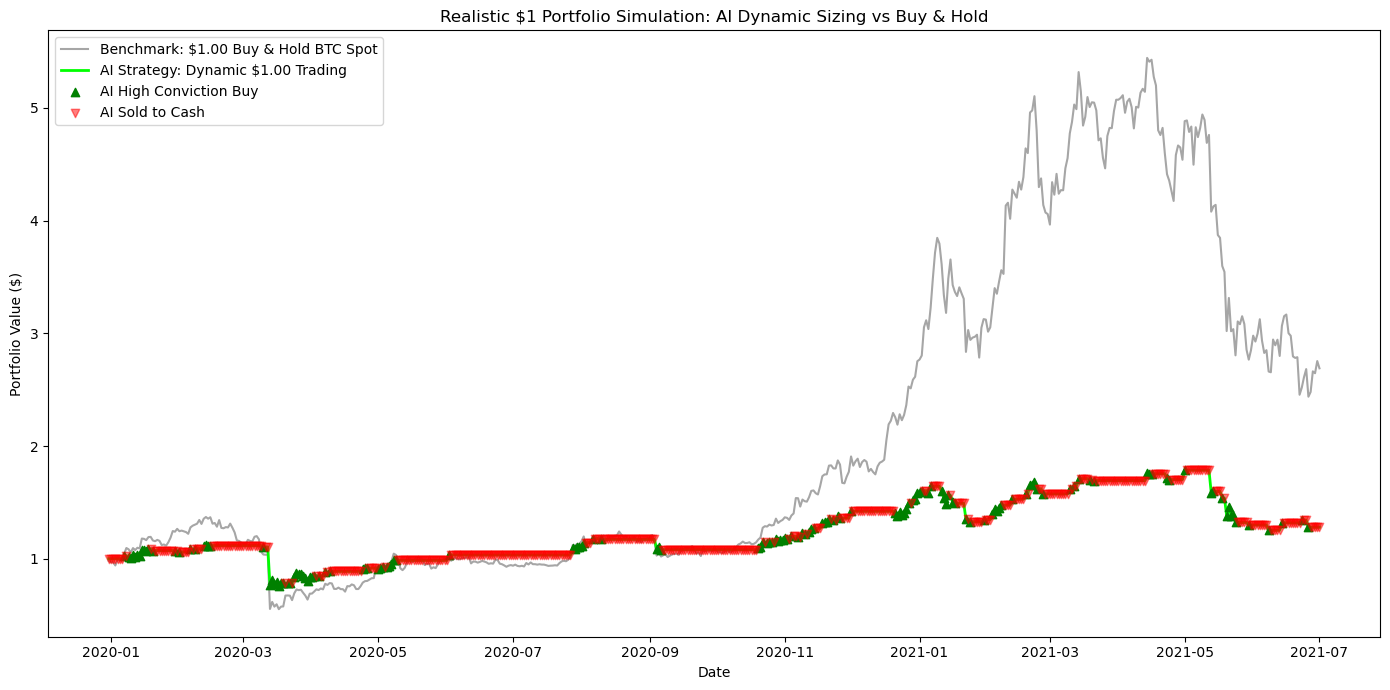

Starting Capital: $1.00
Final Benchmark (Buy & Hold) Value: $2.69
Final AI Portfolio Value: $1.28
AI Outperformance: -52.41%


In [62]:
import numpy as np
import matplotlib.pyplot as plt

# --- Realistic $1 Portfolio Simulation ---
# Addressing your question: Yes, the previous method put 100% of the portfolio in or out.
# Here, we will actively manage a $1 portfolio. We will use the model's 'Prob_Up' 
# to dictate the PERCENTAGE of our portfolio we hold in Bitcoin.
# E.g., If model is 80% confident, we put 80% of our cash into BTC.

initial_capital = 1.00 # Start with exactly $1.00

# 1. Benchmark: Buy & Hold 100% Spot Bitcoin from day 1
backtest_df['Benchmark_Portfolio'] = initial_capital * (1 + backtest_df['Actual_Return']).cumprod()

# 2. AI Strategy: Dynamic Position Sizing based on Confidence (Prob_Up)
# We only take positions if confidence is > 50%. The higher the confidence, the more we allocate.
# Max allocation is 100% (1.0).
backtest_df['Allocation_Pct'] = np.where(backtest_df['Prob_Up'] > 0.5, backtest_df['Prob_Up'], 0.0)

# Calculate strategy returns: Only the allocated percentage experiences the Bitcoin daily return.
# The unallocated cash sits at 0% return.
backtest_df['Strategy_Daily_Return'] = backtest_df['Allocation_Pct'] * backtest_df['Actual_Return']

# Compound the $1.00 portfolio over time
backtest_df['AI_Portfolio_Value'] = initial_capital * (1 + backtest_df['Strategy_Daily_Return']).cumprod()

# --- Plot the Results ---
plt.figure(figsize=(14, 7))

# Plot starting point
dates = backtest_df['Date'].values
plt.plot(dates, backtest_df['Benchmark_Portfolio'], label='Benchmark: $1.00 Buy & Hold BTC Spot', color='gray', alpha=0.7)
plt.plot(dates, backtest_df['AI_Portfolio_Value'], label='AI Strategy: Dynamic $1.00 Trading', color='lime', linewidth=2)

# Show when AI is highly invested (over 70% allocation)
high_conviction = backtest_df[backtest_df['Allocation_Pct'] > 0.3]
plt.scatter(high_conviction['Date'], high_conviction['AI_Portfolio_Value'], color='green', marker='^', label='AI High Conviction Buy', zorder=5)

# Show when AI is completely in cash (0% allocation)
cash_only = backtest_df[backtest_df['Allocation_Pct'] == 0]
plt.scatter(cash_only['Date'], cash_only['AI_Portfolio_Value'], color='red', marker='v', label='AI Sold to Cash', zorder=5, alpha=0.5)

plt.title('Realistic $1 Portfolio Simulation: AI Dynamic Sizing vs Buy & Hold')
plt.ylabel('Portfolio Value ($)')
plt.xlabel('Date')
plt.legend()
plt.tight_layout()
plt.show()

# Print Final Statistics
final_benchmark = backtest_df['Benchmark_Portfolio'].iloc[-1]
final_ai = backtest_df['AI_Portfolio_Value'].iloc[-1]

print(f"Starting Capital: $1.00")
print(f"Final Benchmark (Buy & Hold) Value: ${final_benchmark:.2f}")
print(f"Final AI Portfolio Value: ${final_ai:.2f}")
print(f"AI Outperformance: {((final_ai - final_benchmark)/final_benchmark * 100):.2f}%")
